In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandahouse as ph

In [2]:
connection = {
    'host': 'https://clickhouse.lab.karpov.courses',
    'password': 'dpo_python_2020',
    'user': 'student',
    'database': 'simulator'
}

In [16]:
q_user_activity = """
SELECT
    toHour(time) AS hour,
    count() AS total_actions
FROM simulator_20250520.feed_actions
GROUP BY hour
ORDER BY hour
"""
user_activity_df = ph.read_clickhouse(q_user_activity, connection=connection)

In [17]:
q_posts_published = """
SELECT
    toHour(first_view_time) AS hour,
    count() AS published_posts
FROM (
    SELECT
        min(time) AS first_view_time
    FROM simulator_20250520.feed_actions
    WHERE action = 'view'
    GROUP BY post_id
)
GROUP BY hour
ORDER BY hour
"""
posts_published_df = ph.read_clickhouse(q_posts_published, connection=connection)

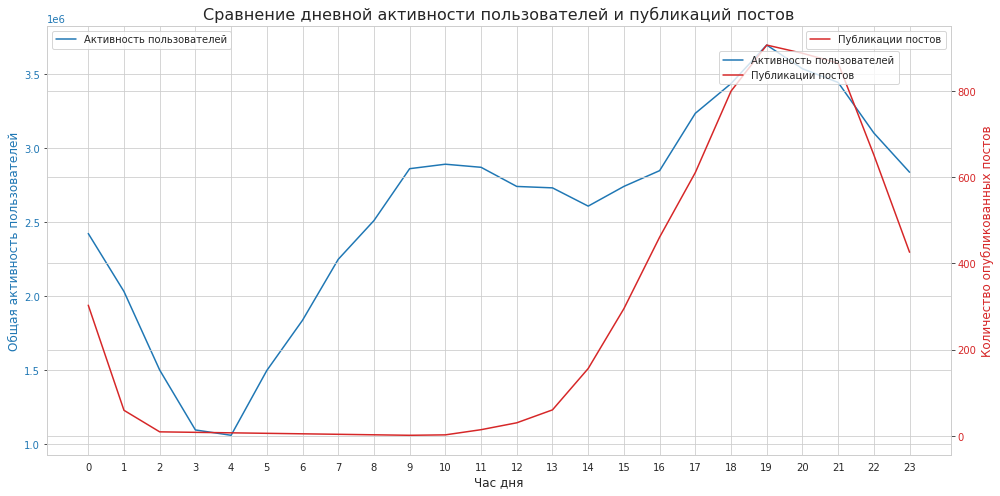

In [20]:
sns.set_style("whitegrid")
fig, ax1 = plt.subplots(figsize=(14, 7))

# График для активности пользователей (синий, левая ось Y)
color1 = 'tab:blue'
ax1.set_xlabel('Час дня', fontsize=12)
ax1.set_ylabel('Общая активность пользователей', color=color1, fontsize=12)
sns.lineplot(x=user_activity_df['hour'], y=user_activity_df['total_actions'], ax=ax1, color=color1, label='Активность пользователей')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(range(0, 24))

# Создаем вторую ось Y для публикаций
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Количество опубликованных постов', color=color2, fontsize=12)
sns.lineplot(x=posts_published_df['hour'], y=posts_published_df['published_posts'], ax=ax2, color=color2, label='Публикации постов')
ax2.tick_params(axis='y', labelcolor=color2)

# Общий заголовок и легенда
plt.title('Сравнение дневной активности пользователей и публикаций постов', fontsize=16)
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
fig.tight_layout()
plt.show()